In [10]:
import os
import numpy as np
import pandas as pd
from torchvision import io

In [11]:
full_dataset_folder = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/Input/data-RGBA'

In [12]:
all_sample_data = []
for eval_result_file in os.listdir('all_eval_results'):
    num_subjects = eval_result_file.split('_')[-1]
    num_subjects = num_subjects.split('.')[0]  # Remove file extension
    eval_result_data = pd.read_csv(os.path.join('all_eval_results', eval_result_file))
    mean_ssim = eval_result_data['SSIM'].mean()
    max_ssim = eval_result_data['SSIM'].max()

    total_pixel_values = 0
    total_pixel_count = 0

    for i in eval_result_data.index:
        file = eval_result_data['Image'][i]

        source_image = io.read_image(os.path.join(full_dataset_folder, file))

        total_pixel_values += np.array(source_image.flatten()).sum()
        total_pixel_count += len(source_image.flatten())
    try:
        discriminator_results = pd.read_csv(os.path.join('discriminator_training_results', f'discriminator_performance_{num_subjects}_samples.csv'))
        all_sample_data.append({
            'num_subjects': int(num_subjects),
            'num_samples': len(eval_result_data),
            'mean_ssim': mean_ssim,
            'max_ssim': max_ssim,
            'percent_above_050': (eval_result_data['SSIM'] > 0.50).sum() / len(eval_result_data),
            'avg_num_pixels': total_pixel_values / total_pixel_count if total_pixel_count > 0 else 0,
            'training_accuracy_25': discriminator_results.loc[25, 'train_acc'],
            'training_accuracy_end': discriminator_results.loc[len(discriminator_results) - 1, 'train_acc'],
        })
    except:
        pass

/tmp/ipykernel_1583534/533423565.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  total_pixel_values += np.array(source_image.flatten()).sum()
/tmp/ipykernel_1583534/533423565.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  total_pixel_values += np.array(source_image.flatten()).sum()
/tmp/ipykernel_1583534/533423565.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  total_pixel_values += np.array(source_image.flatten()).sum()
/tmp/ipykernel_1583534/533423565.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and '

In [13]:
all_sample_data_df = pd.DataFrame(all_sample_data)

In [14]:
all_sample_data_df = all_sample_data_df.drop(6)

In [15]:
all_sample_data_df

,num_subjects,num_samples,mean_ssim,max_ssim,percent_above_050,avg_num_pixels,training_accuracy_25,training_accuracy_end
0,60,590,0.270793,0.744993,0.206780,94.718252,0.916667,0.933333
1,50,490,0.315378,0.742553,0.263265,87.858567,0.870000,0.940000
2,40,400,0.329946,0.733447,0.302500,83.835888,0.812500,0.925000
3,90,890,0.309892,0.778608,0.294382,88.868076,0.961111,0.977778
4,70,680,0.279180,0.703862,0.251471,96.207979,0.950000,0.978571
5,15,150,0.252459,0.658922,0.200000,104.261923,0.500000,0.866667
7,80,790,0.315931,0.772749,0.279747,89.346582,0.925000,0.950000
8,100,1000,0.288981,0.719218,0.289000,91.438495,0.915000,0.950000
9,30,300,0.318330,0.774355,0.263333,89.155679,0.766667,0.916667


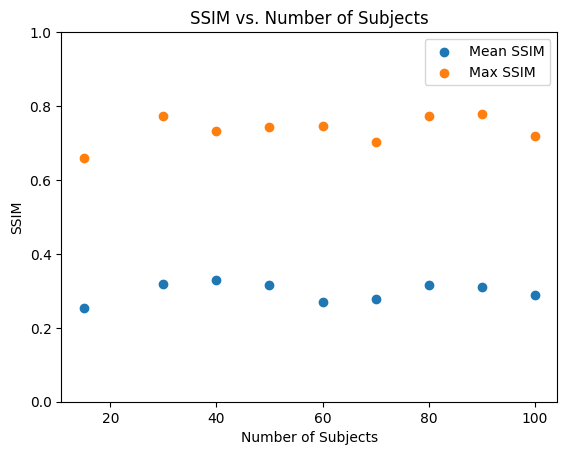

In [16]:
import matplotlib.pyplot as plt
plt.scatter(all_sample_data_df['num_subjects'].values, all_sample_data_df['mean_ssim'].values, label='Mean SSIM')
plt.scatter(all_sample_data_df['num_subjects'].values, all_sample_data_df['max_ssim'].values, label='Max SSIM')
plt.legend()
plt.title('SSIM vs. Number of Subjects')
plt.xlabel('Number of Subjects')
plt.ylabel('SSIM')
plt.ylim(0, 1)
plt.show()

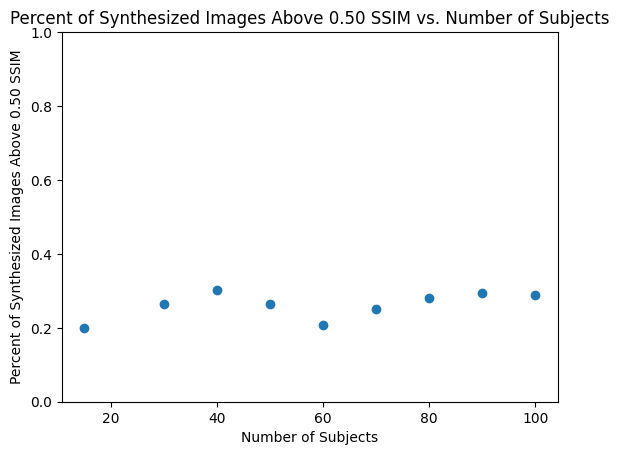

In [19]:

plt.scatter(all_sample_data_df['num_subjects'].values, all_sample_data_df['percent_above_050'].values)

plt.title('Percent of Synthesized Images Above 0.50 SSIM vs. Number of Subjects')
plt.xlabel('Number of Subjects')
plt.ylabel('Percent of Synthesized Images Above 0.50 SSIM')
plt.ylim(0, 1)
plt.show()


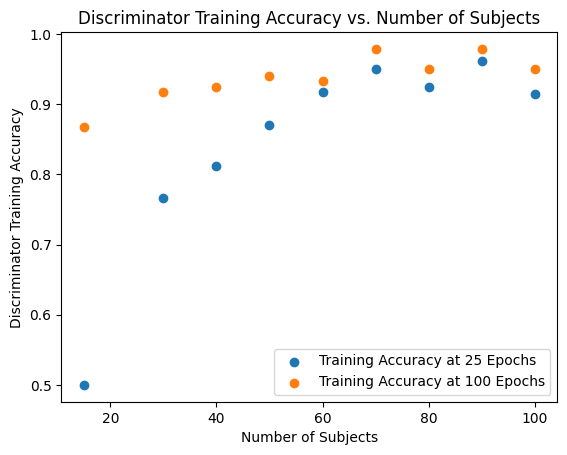

In [18]:
import matplotlib.pyplot as plt
plt.scatter(all_sample_data_df['num_subjects'].values, all_sample_data_df['training_accuracy_25'].values, label="Training Accuracy at 25 Epochs")
plt.scatter(all_sample_data_df['num_subjects'].values, all_sample_data_df['training_accuracy_end'].values, label="Training Accuracy at 100 Epochs")
plt.legend()
plt.title('Discriminator Training Accuracy vs. Number of Subjects')
plt.xlabel('Number of Subjects')
plt.ylabel('Discriminator Training Accuracy')

plt.show()

In [54]:
for i in eval_result_data.index:
    file = eval_result_data['Image'][i]

    source_image = io.read_image(os.path.join(full_dataset_folder, file))
    avg_num_pixels = np.array(source_image.flatten()).mean()

    all_sample_data_df.loc[i, 'avg_num_pixels'] = avg_num_pixels


/tmp/ipykernel_284652/1485203528.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  avg_num_pixels = np.array(source_image.flatten()).mean()
/tmp/ipykernel_284652/1485203528.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  avg_num_pixels = np.array(source_image.flatten()).mean()
/tmp/ipykernel_284652/1485203528.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  avg_num_pixels = np.array(source_image.flatten()).mean()
/tmp/ipykernel_284652/1485203528.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword ar

In [55]:
all_sample_data_df

,num_subjects,num_samples,mean_ssim,avg_num_pixels
0,1.0,20.0,0.384069,36.731653
1,10.0,110.0,0.315909,36.731653
2,25.0,260.0,0.226434,36.731653
3,NaN,NaN,NaN,36.731653
4,NaN,NaN,NaN,36.731653
...,...,...,...,...
255,NaN,NaN,NaN,146.770239
256,NaN,NaN,NaN,146.770239
257,NaN,NaN,NaN,146.770239
258,NaN,NaN,NaN,146.770239


/tmp/ipykernel_284652/1868522835.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.array(source_image.flatten()).mean()


np.float64(36.731653225806454)